In [ ]:
# In[1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# In[2]:

data = pd.read_csv("car_prices.csv", nrows = 100000)
data.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900,30000,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500,27750,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000,67000,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [ ]:
# In[3]:

data.shape

(100000, 16)

In [ ]:
# In[4]:

data = data.drop(['vin', 'trim','saledate','state', 'mmr'], axis = 1)
data.shape

(100000, 11)

In [ ]:
# In[5]:

100*data.isnull().sum()/len(data)

year             0.000
make             0.425
model            0.443
body             2.731
transmission    12.000
condition       11.792
odometer         0.075
color            0.183
interior         0.183
seller           0.000
sellingprice     0.000
dtype: float64

In [ ]:
# In[6]:

data.describe()

,year,condition,odometer,sellingprice
count,100000.000000,88208.000000,99925.000000,100000.000000
mean,2009.293750,29.489037,75147.522172,12230.463520
std,4.256992,13.804882,57711.981006,9333.910641
min,1984.000000,1.000000,1.000000,1.000000
25%,2006.000000,21.000000,29568.000000,5100.000000
50%,2011.000000,33.000000,60953.000000,11000.000000
75%,2013.000000,41.000000,110618.000000,16900.000000
max,2015.000000,49.000000,999999.000000,156000.000000


In [ ]:
# In[7]:

data['condition'].fillna(data['condition'].mean(), inplace=True)
data['odometer'].fillna(data['odometer'].mean(), inplace=True)
data['sellingprice'].fillna(data['sellingprice'].mean(), inplace=True)
data['make'].fillna(data['make'].mode()[0], inplace=True)
data['model'].fillna(data['model'].mode()[0], inplace=True)
data['body'].fillna(data['body'].mode()[0], inplace=True)
data['transmission'].fillna(data['transmission'].mode()[0], inplace=True)
data['color'].fillna(data['color'].mode()[0], inplace=True)
data['interior'].fillna(data['interior'].mode()[0], inplace=True)
data['seller'].fillna(data['seller'].mode()[0], inplace = True)

In [ ]:
# In[8]:

100*data.isnull().sum()/len(data)

year            0.0
make            0.0
model           0.0
body            0.0
transmission    0.0
condition       0.0
odometer        0.0
color           0.0
interior        0.0
seller          0.0
sellingprice    0.0
dtype: float64

In [ ]:
# In[9]:

data['make'] = pd.factorize(data['make'])[0]
data['model'] = pd.factorize(data['model'])[0]
data['body'] = pd.factorize(data['body'])[0]
data['transmission'] = pd.factorize(data['transmission'])[0]
data['color'] = pd.factorize(data['color'])[0]
data['interior'] = pd.factorize(data['interior'])[0]
data['seller'] = pd.factorize(data['seller'])[0]

data.describe()

,year,make,model,body,transmission,condition,odometer,color,interior,seller,sellingprice
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2009.293750,14.575760,164.212160,3.031270,0.033340,29.489037,75147.522172,3.321690,1.947260,1358.616930,12230.463520
std,4.256992,12.923668,141.570016,5.129976,0.179524,12.965414,57690.334737,3.324818,1.977412,1779.973036,9333.910641
min,1984.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2006.000000,4.000000,59.000000,0.000000,0.000000,24.000000,29582.750000,1.000000,0.000000,59.000000,5100.000000
50%,2011.000000,9.000000,157.000000,1.000000,0.000000,29.489037,61022.500000,2.000000,2.000000,727.500000,11000.000000
75%,2013.000000,23.000000,205.000000,3.000000,0.000000,39.000000,110590.250000,4.000000,4.000000,1959.000000,16900.000000
max,2015.000000,92.000000,878.000000,42.000000,1.000000,49.000000,999999.000000,19.000000,16.000000,7086.000000,156000.000000


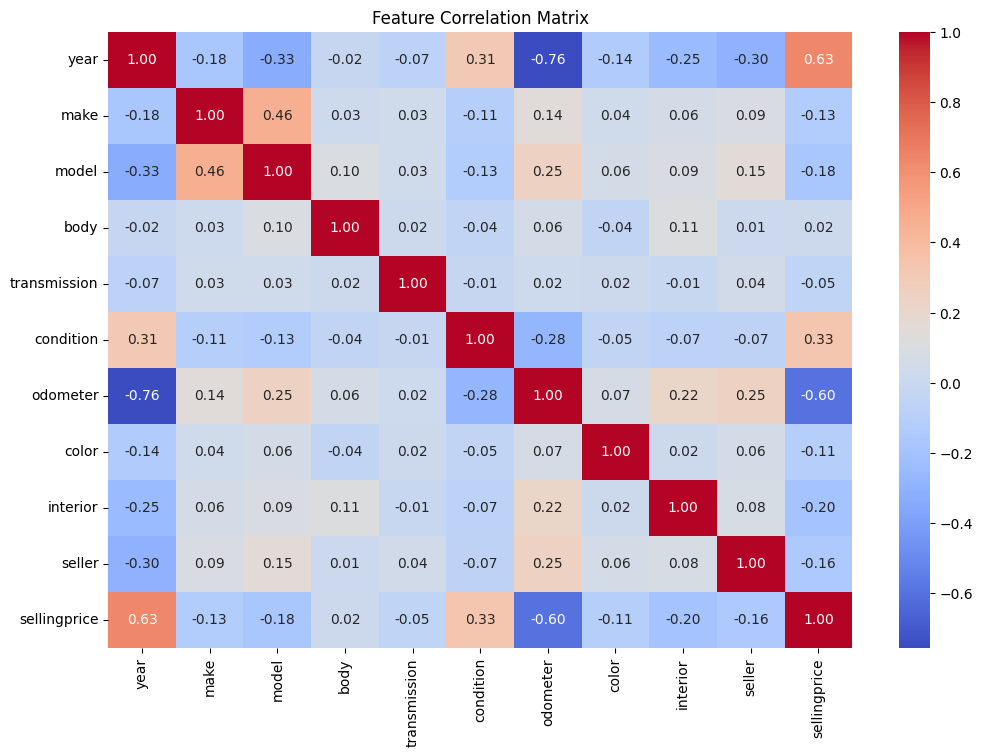

                year           make          model           body  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean     2009.293750      14.575760     164.212160       3.031270   
std         4.256992      12.923668     141.570016       5.129976   
min      1984.000000       0.000000       0.000000       0.000000   
25%      2006.000000       4.000000      59.000000       0.000000   
50%      2011.000000       9.000000     157.000000       1.000000   
75%      2013.000000      23.000000     205.000000       3.000000   
max      2015.000000      92.000000     878.000000      42.000000   

        transmission      condition       odometer          color  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean        0.033340      29.489037   75147.522172       3.321690   
std         0.179524      12.965414   57690.334737       3.324818   
min         0.000000       1.000000       1.000000       0.000000   
25%         0.000000      24.0000

In [ ]:
# In[10]:

correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Feature Correlation Matrix")
plt.show()
print(data.describe())

In [ ]:
# In[11]:

data = data[data['odometer'] < 500000]
data['odometer'] = np.log1p(data['odometer']) 
data['make'] = np.log1p(data['make']) 
data['model'] = np.log1p(data['model']) 
data['body'] = np.log1p(data['body']) 
data['seller']= np.log1p(data['seller'])

In [ ]:
# In[12]:

X = data.drop('sellingprice', axis = 1)
y = data['sellingprice']

In [ ]:
# In[13]:

norm = MinMaxScaler().fit(X)
X = norm.transform(X)

In [ ]:
# In[14]:

Linear_Regression = LinearRegression()
Linear_Regression.fit(X, y)
Linear_Regression.score(X, y)

0.4415446189833282

In [ ]:
# In[15]:

X2 = sm.add_constant(X)
est = sm.OLS(y, X2).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:           sellingprice   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     7904.
Date:                Wed, 11 Dec 2024   Prob (F-statistic):               0.00
Time:                        11:01:04   Log-Likelihood:            -1.0267e+06
No. Observations:               99978   AIC:                         2.053e+06
Df Residuals:                   99967   BIC:                         2.053e+06
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7274.5147    362.056    -20.092      0.0

In [ ]:
# In[16]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [ ]:
# In[17]:

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# In[18]:

print('Train Accuracy = ', round((lr.score(X_train, y_train)), 4)*100,'%')
print('Test Accuracy = ', round((lr.score(X_test, y_test)), 4)*100,'%')

Train Accuracy =  44.1 %
Test Accuracy =  44.36 %


In [ ]:
# In[19]:

y_pred = lr.predict(X_test)
print(y_pred.round(2)[:5])
r2_score(y_test, y_pred)

[15024.82  6958.78 15623.77  7630.75 10719.82]


0.4436383706595758

In [ ]:
# In[20]:

pd.DataFrame({'Actual': y_test.round(2), 'Predicted': y_pred.round(2)})

,Actual,Predicted
8579,23900,15024.82
23866,13250,6958.78
34101,11750,15623.77
20901,4200,7630.75
91541,6500,10719.82
...,...,...
89305,6900,10978.88
36391,16100,21951.29
7056,9300,8411.80
92535,5700,7473.04


In [ ]:
# In[21]:

print("Mean Squared Error: ", mean_squared_error(y_test, y_pred).round(2))
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred).round(2))  
print('Root Mean Squared Error: ', np.sqrt(mean_squared_error(y_test, y_pred)).round(2))

Mean Squared Error:  46736383.33
Mean Absolute Error:  4788.55
Root Mean Squared Error:  6836.4


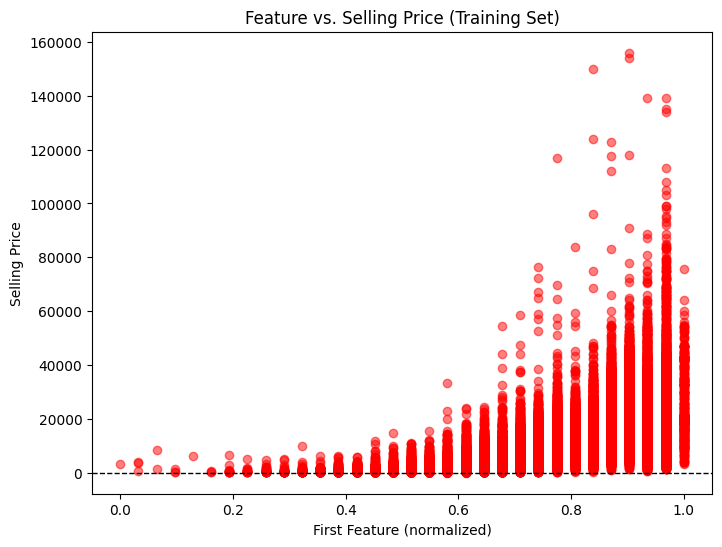

In [ ]:
# In[22]:

plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], y_train, c='red', alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Feature vs. Selling Price (Training Set)')
plt.xlabel('First Feature (normalized)')
plt.ylabel('Selling Price')
plt.show()

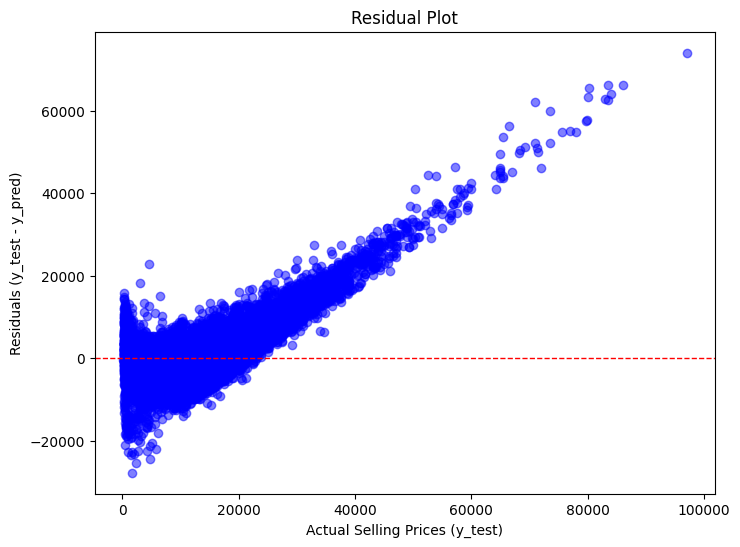

In [ ]:
# In[23]:

# Residual Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test - y_pred, c='blue', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Residual Plot')
plt.xlabel('Actual Selling Prices (y_test)')
plt.ylabel('Residuals (y_test - y_pred)')
plt.show()

In [ ]:
# In[24]:

degree = 6
poly_reg = PolynomialFeatures(degree = degree)
X_poly = poly_reg.fit_transform(X)
pol_reg = LinearRegression()
pol_reg.fit(X_poly, y)

LinearRegression()

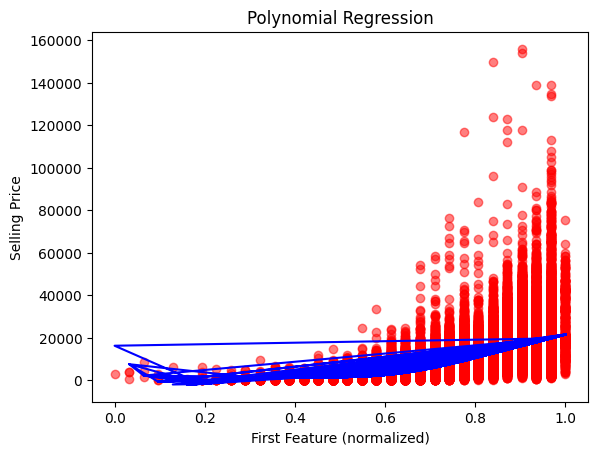

In [ ]:
# In[25]:

def viz_polymonial():
    X_feature = X[:, 0]
    X_feature = X_feature.reshape(-1, 1)

    poly_reg = PolynomialFeatures(degree=degree)
    X_poly = poly_reg.fit_transform(X_feature)
    pol_reg = LinearRegression()
    pol_reg.fit(X_poly, y)

    plt.scatter(X_feature, y, color='red', alpha=0.5)
    plt.plot(X_feature, pol_reg.predict(X_poly), color='blue')
    plt.title('Polynomial Regression')
    plt.xlabel('First Feature (normalized)')
    plt.ylabel('Selling Price')
    plt.show()

viz_polymonial()

In [ ]:
# In[26]:

print(Linear_Regression.predict(X).round())
print("R Square value:", r2_score(y, Linear_Regression.predict(X).round()))

[16280. 16798. 22801. ... 11735.  6451. 11423.]
R Square value: 0.4415445857236361


In [ ]:
# In[27]:

print(pol_reg.predict(poly_reg.fit_transform(X)).round())
print("R Square value:", r2_score(y, pol_reg.predict(poly_reg.fit_transform(X)).round()))

mae_poly = mean_absolute_error(y, pol_reg.predict(poly_reg.fit_transform(X)).round())
mse_poly = mean_squared_error(y, pol_reg.predict(poly_reg.fit_transform(X)).round())
rmse_poly = np.sqrt(mse_poly)

print("Polynomial Regression:")
print("Mean Absolute Error (MSE):", mse_poly.round(2))
print("Mean Absolute Error (MAE):", mae_poly.round(2))
print("Root Mean Squared Error (RMSE):", rmse_poly.round(2))

[21896. 19827. 37261. ... 11681.  5074.  8392.]
R Square value: 0.7485688989505443
Polynomial Regression:
Mean Absolute Error (MSE): 21903424.93
Mean Absolute Error (MAE): 2939.31
Root Mean Squared Error (RMSE): 4680.11
